# 动手学 AI：连续时间生存分析与 DeepSurv 房贷提前还款建模

本笔记本配套**第二章：机会与提前还款**中的**“机器学习桥梁：概率论到统计学习”**小节。

## 核心金融挑战：右删失与非线性核保摩擦
在抵押贷款金融学中，借款人的提前还款行为并非普通的二元分类目标（是否违约），而是一个**受控于条件危险率 $\lambda(t)$ 的连续时间生存过程（Continuous-Time Survival Process）**，并伴随严重的**右删失（Right Censoring）**：
- 当我们在 5 年（60 个月）的时间窗口内追踪一个贷款批次时，大量贷款在观察期结束时依然在正常履约、尚未结清（$E_i = 0$）；
- 若直接丢弃这批正常履约贷款，或粗暴地将其标记为“永远不还”，会引发严重的样本选择偏差。

经典半参数 **Cox 比例风险回归（Cox Proportional Hazards Model，1972）** 假定：
$$\lambda(t \mid x) = \lambda_0(t) \exp(\beta^\top x)$$

该模型施加了极其刚性的先验假设：每一个特征都必须对基线危险率产生**时间与空间上恒定不变的比例乘性放大**（$\exp(\beta_k)$）。

### 经典 Cox 模型在房贷中的结构性失效
真实世界的信贷核保摩擦打破了这一恒定比例：
- 面对即使高达 150 bp 的降息再融资利差，若借款人的信用分过低（FICO < 660）或房屋陷入高负债（LTV > 85%），其再融资审批**会被直接否决**；
- 换言之，信用资质构成了降息激励的**非线性“闸门（Gating Mechanism）”**。

**DeepSurv（Katzman et al., 2018）** 将线性组合 $\beta^\top x$ 升级为多层深度神经网络 $h_\theta(x)$，直接在右删失数据上最大化 Cox 偏对数似然函数进行端到端训练。


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# 限制 CPU 线程池防止小张量锁竞争
torch.set_num_threads(4)

# 设置随机种子保证结果可精确复现
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "axes.unicode_minus": False,
})

# 设置支持中文的字体
plt.rcParams["font.sans-serif"] = ["WenQuanYi Zen Hei", "WenQuanYi Micro Hei", "Noto Sans CJK JP", "DejaVu Sans"]

print(f"PyTorch 版本: {torch.__version__} | 当前活跃 CPU 线程数: {torch.get_num_threads()}")


PyTorch 版本: 2.10.0+cu128 | 当前活跃 CPU 线程数: 4


## 1. 模拟含右删失的房贷生存数据

我们模拟 2,500 笔在 60 个月追踪窗口内的抵押贷款：
- **incentive_bp**：再融资利差激励（契约利率 - 市场利率），单位为基点；
- **fico**：借款人信用分（620 至 820 分）；
- **ltv**：贷款价值比（48% 至 95%）；
- **balance**：贷款初始未偿还本金余额（均值约 27 万美元）。

贷款提前还款时间由含核保摩擦闸门的非线性 Weibull 危险率生成。在 60 个月期末尚未还清的贷款自动标记为右删失（$E_i = 0$）。


In [2]:
def generate_mortgage_survival_data(
    n_loans: int = 2000,
    max_months: float = 60.0,
    seed: int = SEED,
):
    """Simulates mortgage loan prepayment survival times with right-censoring.
    
    Features:
        - incentive_bp: Refinance incentive in basis points (-150 to +250 bp)
        - fico: Borrower credit score (620 to 820)
        - ltv: Loan-to-value ratio (50% to 95%)
        - balance_log: Log loan size (log($100k) to log($650k))
    
    True log-hazard function:
        High refi incentive accelerates payoff, BUT ONLY if the borrower has
        adequate credit qualification (FICO > 700 and LTV < 80). Impaired
        borrowers face sharp underwriting frictions.
    """
    rng = np.random.default_rng(seed)

    incentive_bp = rng.normal(50.0, 80.0, size=n_loans)           # basis points
    fico = np.clip(rng.normal(735.0, 40.0, size=n_loans), 620, 820)
    ltv = np.clip(rng.normal(76.0, 10.0, size=n_loans), 48.0, 95.0)
    balance = rng.lognormal(mean=12.5, sigma=0.4, size=n_loans)   # ~$270k

    # Normalized feature matrix for modeling
    x_mat = np.column_stack([
        incentive_bp / 100.0,              # 100 bp = 1 unit
        (fico - 720.0) / 100.0,            # centered at 720
        (ltv - 75.0) / 10.0,               # centered at 75%
        (np.log(balance) - 12.5),          # centered log-balance
    ])

    # True non-linear log hazard ratio (incorporating credit friction gating)
    # Refinancing gate: Sigmoid credit friction
    credit_gate = (
        (1.0 / (1.0 + np.exp(-(fico - 690.0) / 20.0))) *
        (1.0 / (1.0 + np.exp((ltv - 82.0) / 5.0)))
    )
    # Base turnover hazard. -4.5 leaves about 36% of loans still open at
    # month 60, which is what a real pool looks like five years in; at -2.8
    # nearly every synthetic loan paid off and there was nothing to censor.
    base_hazard = -4.5
    # Non-linear interaction: incentive is only realized through the credit gate
    true_log_hazard = (
        base_hazard +
        2.5 * np.maximum(0.0, incentive_bp / 100.0) * credit_gate -
        0.5 * (ltv > 85.0)
    )

    # Invert hazard to generate Weibull-distributed survival times
    # T = (-log(U) / (lambda * dt))^(1 / shape)
    u = rng.uniform(0.0001, 0.9999, size=n_loans)
    scale = np.exp(-true_log_hazard)
    shape = 1.3  # slight seasoning ramp
    event_times = scale * (-np.log(u)) ** (1.0 / shape)

    # Right-censoring: study ends at max_months (e.g. 60 months)
    censoring_times = rng.uniform(max_months * 0.7, max_months * 1.3, size=n_loans)
    censoring_times = np.clip(censoring_times, 1.0, max_months)

    observed_durations = np.minimum(event_times, censoring_times)
    event_observed = (event_times <= censoring_times).astype(np.float32)

    return (
        torch.tensor(x_mat, dtype=torch.float32),
        torch.tensor(observed_durations, dtype=torch.float32),
        torch.tensor(event_observed, dtype=torch.float32),
    )

x, durations, events = generate_mortgage_survival_data(n_loans=2500)

n_train = 1875
x_train, x_test = x[:n_train], x[n_train:]
dur_train, dur_test = durations[:n_train], durations[n_train:]
evt_train, evt_test = events[:n_train], events[n_train:]

censored_pct = (1.0 - float(evt_train.mean())) * 100.0
print(f"成功生成 2,500 笔贷款（训练集: {n_train} 笔，留出测试集: {len(x_test)} 笔）。")
print(f"训练集中右删失贷款占比: {censored_pct:.1f}%")
print(f"平均观测存续期: {dur_train.mean():.1f} 个月。")


成功生成 2,500 笔贷款（训练集: 1875 笔，留出测试集: 625 笔）。
训练集中右删失贷款占比: 36.1%
平均观测存续期: 33.1 个月。


## 2. Cox 偏似然损失函数与一致性指数（C-Index）

**Cox 负对数偏似然函数（Negative Log Partial Likelihood）** 仅针对真实发生提前还款的样本（$E_i = 1$）进行评估：
$$\mathcal{L}(\theta) = - \sum_{i: E_i=1} \left[ h_\theta(x_i) - \log \sum_{j \in \mathcal{R}(T_i)} \exp(h_\theta(x_j)) \right]$$

在模型评估上，生存分析使用 **Harrell 一致性指数（C-Index）**：
- 考察所有先于贷款 $j$ 提前结清的贷款对 $(i, j)$；
- 若模型赋予贷款 $i$ 更高的相对危险率得分（$h(x_i) > h(x_j)$），则称该对一致；
- $C = 0.5$ 相当于随机乱猜，$C = 1.0$ 为完美排序区分。


In [3]:
def negative_log_partial_likelihood(risk_scores, durations, events):
    order = torch.argsort(durations, descending=True)
    sorted_risk = risk_scores[order].squeeze(-1)
    sorted_events = events[order].squeeze(-1)

    log_cum_sum = torch.logcumsumexp(sorted_risk, dim=0)
    event_mask = sorted_events > 0.5
    if not event_mask.any():
        return torch.tensor(0.0, requires_grad=True)

    log_lik = sorted_risk[event_mask] - log_cum_sum[event_mask]
    return -torch.mean(log_lik)

def compute_concordance_index(risk_scores, durations, events):
    risk = risk_scores.flatten()
    dur = durations.flatten()
    evt = events.flatten()

    concordant, permissible = 0.0, 0.0
    n = len(dur)
    for i in range(n):
        if evt[i] == 0:
            continue
        for j in range(n):
            if dur[i] < dur[j]:
                permissible += 1.0
                if risk[i] > risk[j]:
                    concordant += 1.0
                elif risk[i] == risk[j]:
                    concordant += 0.5

    return concordant / permissible if permissible > 0 else 0.5

print("偏似然损失函数与 Harrell 一致性指数计算模块就绪。")


偏似然损失函数与 Harrell 一致性指数计算模块就绪。


## 3. 模型训练：经典线性 Cox vs. DeepSurv 深度生存网络

我们对比两类模型：
1. **线性 Cox 模型**：$h(x) = \beta^\top x$（对应计量经济学中的经典半参数生存回归）；
2. **DeepSurv 神经网络**：$h(x) = \text{MLP}(x)$，采用 SELU 激活函数。


In [4]:
class LinearCoxModel(nn.Module):
    def __init__(self, in_features=4):
        super().__init__()
        self.linear = nn.Linear(in_features, 1, bias=False)

    def forward(self, x):
        return self.linear(x)

class DeepSurvModel(nn.Module):
    def __init__(self, in_features=4, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.SELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SELU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x)

# 1. 拟合线性 Cox 模型
torch.manual_seed(SEED)
model_cox = LinearCoxModel(in_features=4)
opt_cox = torch.optim.Adam(model_cox.parameters(), lr=0.02)

for epoch in range(350):
    opt_cox.zero_grad()
    loss = negative_log_partial_likelihood(model_cox(x_train), dur_train, evt_train)
    loss.backward()
    opt_cox.step()

with torch.no_grad():
    cox_test_risk = model_cox(x_test).numpy()
c_index_cox = compute_concordance_index(cox_test_risk, dur_test.numpy(), evt_test.numpy())
beta = model_cox.linear.weight.detach().numpy().flatten()
print(f"线性 Cox 拟合权重: 利差={beta[0]:.2f}, FICO={beta[1]:.2f}, LTV={beta[2]:.2f}, 余额={beta[3]:.2f}")
print(f"线性 Cox 样本外测试集 C-Index: {c_index_cox:.4f}")

# 2. 训练 DeepSurv 网络
torch.manual_seed(SEED)
model_ds = DeepSurvModel(in_features=4, hidden_dim=32)
opt_ds = torch.optim.Adam(model_ds.parameters(), lr=0.005, weight_decay=1e-4)

for epoch in range(350):
    opt_ds.zero_grad()
    loss = negative_log_partial_likelihood(model_ds(x_train), dur_train, evt_train)
    loss.backward()
    opt_ds.step()

with torch.no_grad():
    ds_test_risk = model_ds(x_test).numpy()
c_index_ds = compute_concordance_index(ds_test_risk, dur_test.numpy(), evt_test.numpy())
print(f"DeepSurv 深度生存网络样本外测试集 C-Index: {c_index_ds:.4f}")
print(f"DeepSurv 与 Cox 的 C-Index 之差: {(c_index_ds - c_index_cox)*100:+.1f} 个点")


线性 Cox 拟合权重: 利差=1.08, FICO=0.79, LTV=-0.54, 余额=0.05
线性 Cox 样本外测试集 C-Index: 0.7658


DeepSurv 深度生存网络样本外测试集 C-Index: 0.7899
DeepSurv 与 Cox 的 C-Index 之差: +2.4 个点


## 4. 可视化四类典型借款人画像的条件生存曲线

我们定义四类借款人画像，推演其条件生存曲线 $S(t \mid x) = \exp(-\Lambda_0(t) \exp(h(x)))$：
- **画像 A（高利差 + 高信用）**：+150 bp 息差，780 FICO，68% LTV。准备秒转贷；
- **画像 B（高利差 + 低信用 / 被卡住）**：+150 bp 息差，640 FICO，88% LTV。受困于核保门槛，空有息差无法转贷；
- **画像 C（在价外 + 高信用）**：-50 bp 息差，780 FICO，68% LTV。正常换房搬迁的慢速长尾；
- **画像 D（在价外 + 低信用）**：-50 bp 息差，640 FICO，88% LTV。被动低还款基线。


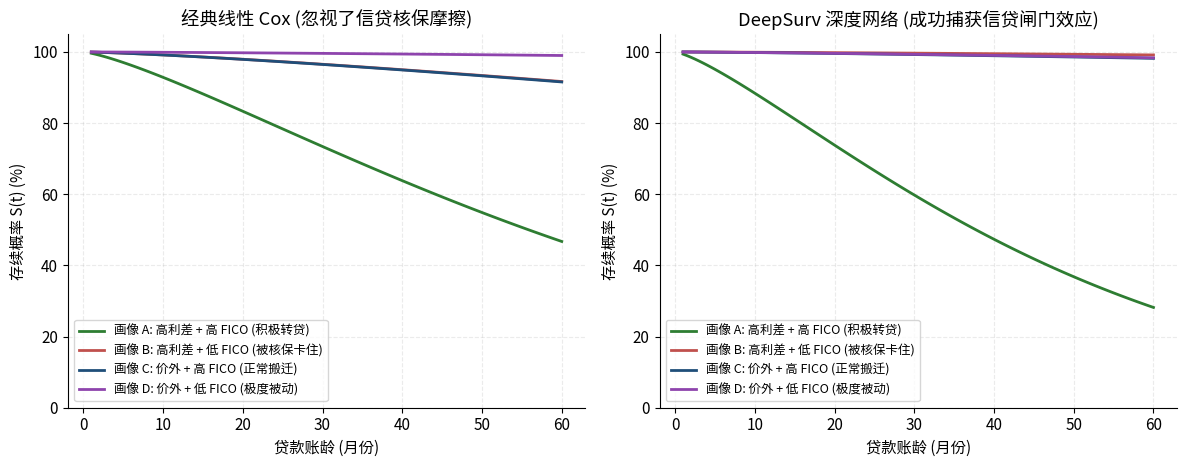

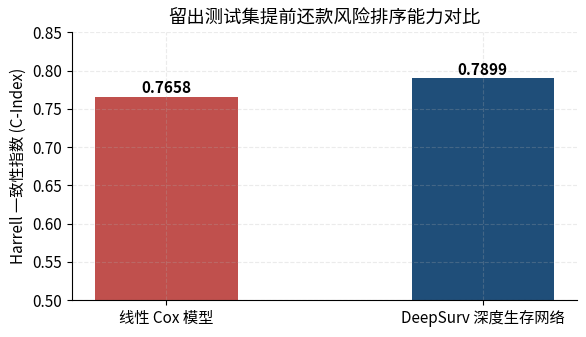

In [5]:
profiles = {
    "画像 A: 高利差 + 高 FICO (积极转贷)": [1.50, (780 - 720)/100, (68 - 75)/10, 0.0],
    "画像 B: 高利差 + 低 FICO (被核保卡住)": [1.50, (640 - 720)/100, (88 - 75)/10, 0.0],
    "画像 C: 价外 + 高 FICO (正常搬迁)": [-0.50, (780 - 720)/100, (68 - 75)/10, 0.0],
    "画像 D: 价外 + 低 FICO (极度被动)": [-0.50, (640 - 720)/100, (88 - 75)/10, 0.0],
}

prof_tensor = torch.tensor(list(profiles.values()), dtype=torch.float32)
with torch.no_grad():
    prof_risk_cox = model_cox(prof_tensor).numpy().flatten()
    prof_risk_ds = model_ds(prof_tensor).numpy().flatten()

time_grid = np.linspace(1, 60, 120)
lambda_0_t = 0.008 * (time_grid / 12.0) ** 1.3

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8))
colors = ["#2e7d32", "#c0504d", "#1f4e79", "#8e44ad"]

# 左图: 线性 Cox
for (name, _), color, r in zip(profiles.items(), colors, prof_risk_cox):
    surv = np.exp(-lambda_0_t * np.exp(r))
    ax1.plot(time_grid, surv * 100, label=name, color=color, lw=2)
ax1.set_title("经典线性 Cox (忽视了信贷核保摩擦)")
ax1.set_xlabel("贷款账龄 (月份)")
ax1.set_ylabel("存续概率 S(t) (%)")
ax1.set_ylim(0, 105)
ax1.legend(frameon=True, fontsize=9)

# 右图: DeepSurv
for (name, _), color, r in zip(profiles.items(), colors, prof_risk_ds):
    surv = np.exp(-lambda_0_t * np.exp(r))
    ax2.plot(time_grid, surv * 100, label=name, color=color, lw=2)
ax2.set_title("DeepSurv 深度网络 (成功捕获信贷闸门效应)")
ax2.set_xlabel("贷款账龄 (月份)")
ax2.set_ylabel("存续概率 S(t) (%)")
ax2.set_ylim(0, 105)
ax2.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

# C-Index 柱状对比图
fig, ax = plt.subplots(figsize=(6, 3.5))
models = ["线性 Cox 模型", "DeepSurv 深度生存网络"]
c_indices = [c_index_cox, c_index_ds]
bar_colors = ["#c0504d", "#1f4e79"]
bars = ax.bar(models, c_indices, color=bar_colors, width=0.45)
ax.set_ylabel("Harrell 一致性指数 (C-Index)")
ax.set_title("留出测试集提前还款风险排序能力对比")
for bar, val in zip(bars, c_indices):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f"{val:.4f}", ha="center", fontweight="bold")
ax.set_ylim(0.5, 0.85)
plt.tight_layout()
plt.show()


## 5. 交易台实务量化启示

1. **线性比例假设的致命盲区**：线性 Cox 回归强制认为 FICO 与再融资利差是两个平行的线性驱动因素。它会荒谬地预测“低 FICO 但高息差的借款人”依然会以接近极快速度提前还款；
2. **核保摩擦的阶跃效应**：在真实交易中，低 FICO / 高 LTV 的资产构成了“被困资本”，会在降息浪潮中延长存续期（Extension Risk）。DeepSurv 在没有人工干预的情况下，自动从数据中挖掘出这一非线性闸门；
3. **交易台落地价值**：更高的 C-Index 排序能力直接转化为大宗全贷款资产包（Whole Loan Package）投标中的定价优势，并为对冲交易员（Elena）提供更精准的资产池久期推演。
